In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

In [2]:
# Paths
CLEAN_CSV   = Path("../data/processed/tabular_data/angles_dataset_clean.csv")
OUTPUT_DIR  = Path("../data/processed/tabular_data")
SCALER_PATH = Path("../data/models/scaler.pkl")
OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = Path("../data/figures/03_data_preparation")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load
df = pd.read_csv(CLEAN_CSV)

print("✅ Cleaned dataset loaded.")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {list(df.columns)}")
display(df.head())

✅ Cleaned dataset loaded.
   Shape   : (27051, 32)
   Columns : ['video_id', 'frame_number', 'left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle', 'shoulder_z_diff', 'hip_z_diff', 'torso_rotation', 'left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity', 'exercise_name', 'exercise_correctness', 'exercise_name_encoded', 'exercise_correctness_encoded']


,video_id,frame_number,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,left_hip_angle,right_hip_angle,left_knee_angle,right_knee_angle,...,right_knee_angle_velocity,left_ankle_angle_velocity,right_ankle_angle_velocity,shoulder_z_diff_velocity,hip_z_diff_velocity,torso_rotation_velocity,exercise_name,exercise_correctness,exercise_name_encoded,exercise_correctness_encoded
0,0,0,165.92,176.17,160.69,173.34,168.20,173.08,176.95,171.07,...,0.0,0.0,0.0,0.00,0.00,0.00,pullup,correct,0,1
1,0,1,167.38,178.32,160.27,171.76,168.42,173.78,177.05,175.20,...,123.9,87.6,376.2,0.29,0.12,0.16,pullup,correct,0,1
2,0,2,166.59,179.51,158.92,169.74,168.47,174.47,177.16,176.46,...,37.8,234.6,13.2,2.01,1.17,0.84,pullup,correct,0,1
3,0,3,165.42,177.20,158.65,168.31,167.29,174.86,176.81,177.64,...,35.4,127.8,60.9,2.54,0.03,2.51,pullup,correct,0,1
4,0,4,166.39,173.75,158.61,165.83,167.67,174.92,176.35,179.51,...,56.1,483.9,106.5,0.39,0.26,0.13,pullup,correct,0,1


In [3]:
# Columns that are not features
NON_FEATURE_COLS = [
    "video_id",
    "frame_number",
    "exercise_name",
    "exercise_correctness",
    "exercise_name_encoded",
    "exercise_correctness_encoded"
]

# Features
feature_cols = [col for col in df.columns if col not in NON_FEATURE_COLS]

# Labels
X = df[feature_cols]
y_exercise    = df["exercise_name_encoded"]         # 4 classes: pullup, pushup, russian_twist, squat
y_correctness = df["exercise_correctness_encoded"]  # binary: 1=correct, 0=incorrect

print(f"✅ Features selected: {len(feature_cols)} columns")
print(f"   Feature columns : {feature_cols}")
print(f"\n   Exercise label distribution:\n{y_exercise.value_counts()}")
print(f"\n   Correctness label distribution:\n{y_correctness.value_counts()}")

✅ Features selected: 26 columns
   Feature columns : ['left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle', 'shoulder_z_diff', 'hip_z_diff', 'torso_rotation', 'left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity']

   Exercise label distribution:
exercise_name_encoded
2    7129
1    6978
3    6637
0    6307
Name: count, dtype: int64

   Correctness label distribution:
exercise_correctness_encoded
0    13606
1    13445
Name: count, dtype: int64


In [4]:
# ── Video-level stratified split (fixes frame leakage) ───────────────────────
# Get one representative row per video (exercise + correctness labels)
video_meta = df.groupby("video_id")[["exercise_name_encoded", "exercise_correctness_encoded"]].first().reset_index()

# Combined stratification key: exercise × correctness (8 combinations)
video_meta["stratify_key"] = (
    video_meta["exercise_name_encoded"].astype(str) + "_" +
    video_meta["exercise_correctness_encoded"].astype(str)
)

# 70% train / 30% temp  — stratified by exercise × correctness
train_ids, temp_ids = train_test_split(
    video_meta["video_id"],
    test_size=0.30,
    stratify=video_meta["stratify_key"],
    random_state=42
)

# 15% val / 15% test  — from the 30% temp
temp_meta = video_meta[video_meta["video_id"].isin(temp_ids)]
val_ids, test_ids = train_test_split(
    temp_meta["video_id"],
    test_size=0.50,
    stratify=temp_meta["stratify_key"],
    random_state=42
)

# Assign all frames from each video to the correct split
train_df = df[df["video_id"].isin(train_ids)]
val_df   = df[df["video_id"].isin(val_ids)]
test_df  = df[df["video_id"].isin(test_ids)]

# Extract features and labels
X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

y_ex_train  = train_df["exercise_name_encoded"].reset_index(drop=True)
y_ex_val    = val_df["exercise_name_encoded"].reset_index(drop=True)
y_ex_test   = test_df["exercise_name_encoded"].reset_index(drop=True)

y_cor_train = train_df["exercise_correctness_encoded"].reset_index(drop=True)
y_cor_val   = val_df["exercise_correctness_encoded"].reset_index(drop=True)
y_cor_test  = test_df["exercise_correctness_encoded"].reset_index(drop=True)

print("✅ Video-level split complete — no frame leakage.")
print(f"   Train : {train_df['video_id'].nunique()} videos → {len(X_train)} frames ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Val   : {val_df['video_id'].nunique()} videos → {len(X_val)} frames ({len(X_val)/len(df)*100:.1f}%)")
print(f"   Test  : {test_df['video_id'].nunique()} videos → {len(X_test)} frames ({len(X_test)/len(df)*100:.1f}%)")

# Sanity check — no class should be 0 in any split
print("\n📊 Frame distribution per split (exercise × correctness):")
for name, sdf in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name}:")
    print(sdf.groupby(["exercise_name_encoded", "exercise_correctness_encoded"]).size().unstack(fill_value=0))

✅ Video-level split complete — no frame leakage.
   Train : 170 videos → 18608 frames (68.8%)
   Val   : 37 videos → 4304 frames (15.9%)
   Test  : 37 videos → 4139 frames (15.3%)

📊 Frame distribution per split (exercise × correctness):

Train:
exercise_correctness_encoded     0     1
exercise_name_encoded                   
0                             2314  2032
1                             2334  2530
2                             2503  2449
3                             2290  2156

Val:
exercise_correctness_encoded    0    1
exercise_name_encoded                 
0                             488  497
1                             506  528
2                             586  556
3                             534  609

Test:
exercise_correctness_encoded    0    1
exercise_name_encoded                 
0                             499  477
1                             521  559
2                             469  566
3                             562  486


In [5]:
# Fit ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrames to preserve column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=feature_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols)

# Save the scaler for use in the inference pipeline later
joblib.dump(scaler, SCALER_PATH)

print("✅ Scaler fitted on training data and saved.")
print(f"   Saved to : {SCALER_PATH}")
print(f"\n   Training data mean (first 3 features)  : {scaler.mean_[:3].round(4)}")
print(f"   Training data scale (first 3 features) : {scaler.scale_[:3].round(4)}")

✅ Scaler fitted on training data and saved.
   Saved to : ..\data\models\scaler.pkl

   Training data mean (first 3 features)  : [118.3511 117.2802  66.7675]
   Training data scale (first 3 features) : [44.8789 45.9011 48.9652]


In [6]:
def save_split(X_scaled, y_exercise, y_correctness, video_ids, frame_numbers, split_name):
    split_df = X_scaled.copy()
    split_df["video_id"]                     = video_ids.values
    split_df["frame_number"]                 = frame_numbers.values
    split_df["exercise_name_encoded"]        = y_exercise.values
    split_df["exercise_correctness_encoded"] = y_correctness.values
    path = OUTPUT_DIR / f"{split_name}.csv"
    split_df.to_csv(path, index=False)
    print(f"   ✅ {split_name}.csv saved → {split_df.shape[0]} rows, {split_df.shape[1]} columns")

save_split(X_train_scaled, y_ex_train, y_cor_train,
           train_df["video_id"].reset_index(drop=True),
           train_df["frame_number"].reset_index(drop=True), "train")

save_split(X_val_scaled, y_ex_val, y_cor_val,
           val_df["video_id"].reset_index(drop=True),
           val_df["frame_number"].reset_index(drop=True), "val")

save_split(X_test_scaled, y_ex_test, y_cor_test,
           test_df["video_id"].reset_index(drop=True),
           test_df["frame_number"].reset_index(drop=True), "test")

print(f"\n✅ All splits saved to: {OUTPUT_DIR}")

   ✅ train.csv saved → 18608 rows, 30 columns
   ✅ val.csv saved → 4304 rows, 30 columns
   ✅ test.csv saved → 4139 rows, 30 columns

✅ All splits saved to: ..\data\processed\tabular_data


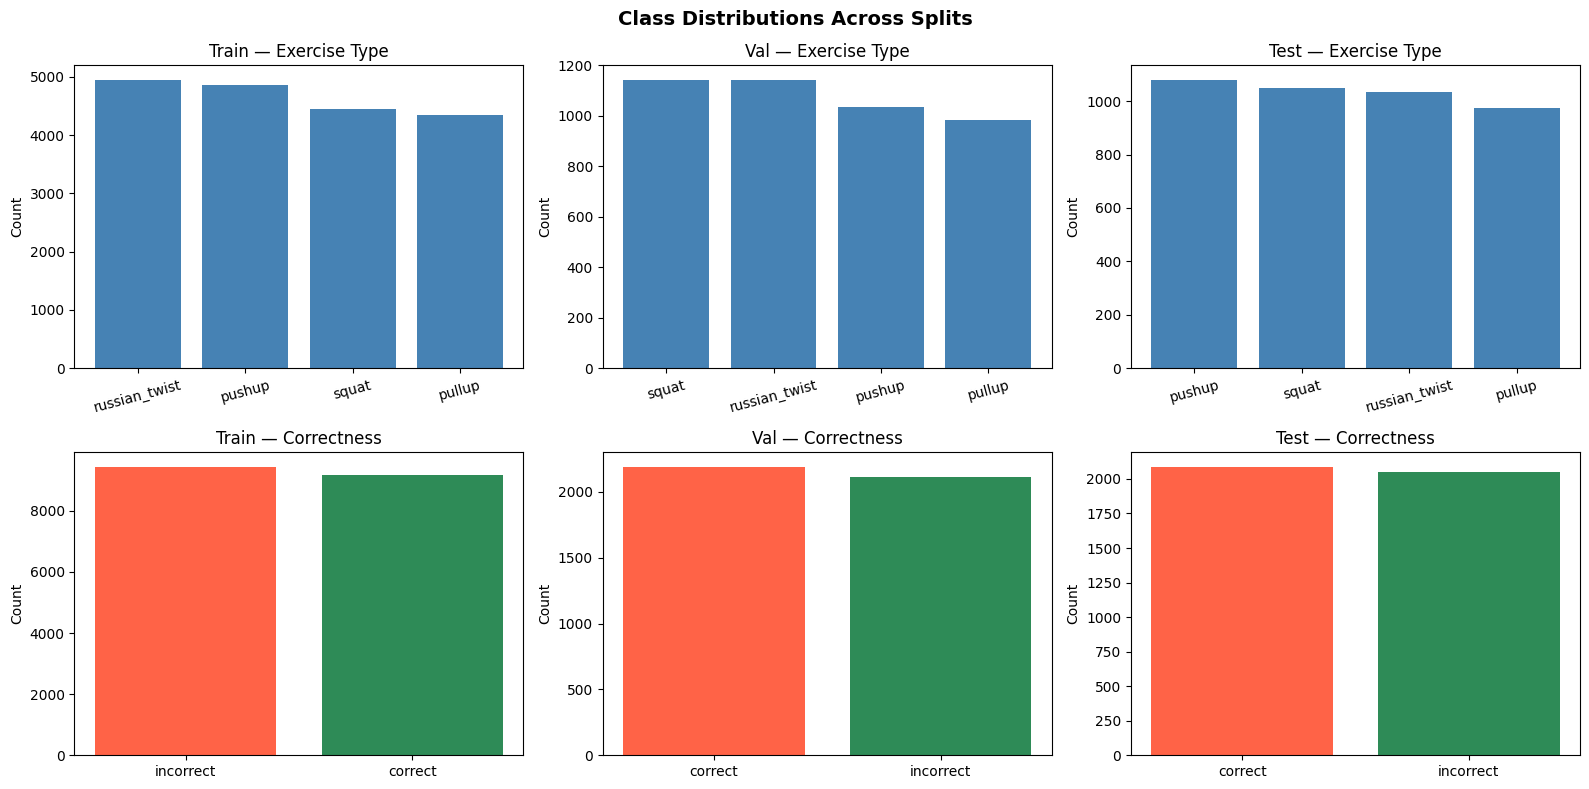

✅ Distribution plot saved.


In [7]:
exercise_map   = {0: "pullup", 1: "pushup", 2: "russian_twist", 3: "squat"}
correctness_map = {0: "incorrect", 1: "correct"}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Class Distributions Across Splits", fontsize=14, fontweight="bold")

splits = {
    "Train": (y_ex_train, y_cor_train),
    "Val"  : (y_ex_val,   y_cor_val),
    "Test" : (y_ex_test,  y_cor_test)
}

for col, (split_name, (y_ex, y_cor)) in enumerate(splits.items()):

    # Exercise distribution
    ex_counts = y_ex.map(exercise_map).value_counts()
    axes[0, col].bar(ex_counts.index, ex_counts.values, color="steelblue")
    axes[0, col].set_title(f"{split_name} — Exercise Type")
    axes[0, col].set_ylabel("Count")
    axes[0, col].tick_params(axis="x", rotation=15)

    # Correctness distribution
    cor_counts = y_cor.map(correctness_map).value_counts()
    axes[1, col].bar(cor_counts.index, cor_counts.values, color=["tomato", "seagreen"])
    axes[1, col].set_title(f"{split_name} — Correctness")
    axes[1, col].set_ylabel("Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "split_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Distribution plot saved.")

In [8]:
print("=" * 55)
print("        02_data_preparation.ipynb — SUMMARY")
print("=" * 55)

print(f"\n📂 Input  : {CLEAN_CSV}")
print(f"📂 Output : {OUTPUT_DIR}")
print(f"📂 Scaler : {SCALER_PATH}")

print(f"\n📊 Dataset split (70/15/15):")
print(f"   Train : {X_train_scaled.shape[0]} rows")
print(f"   Val   : {X_val_scaled.shape[0]} rows")
print(f"   Test  : {X_test_scaled.shape[0]} rows")

print(f"\n🔢 Features : {len(feature_cols)} columns")
print(f"   {feature_cols}")

print(f"\n🏷️  Labels:")
print(f"   exercise_name_encoded      → {sorted(y_exercise.unique())} ({[exercise_map[i] for i in sorted(y_exercise.unique())]})")
print(f"   exercise_correctness_encoded → 0=incorrect, 1=correct")

print(f"\n✅ Files saved:")
print(f"   train.csv, val.csv, test.csv  → {OUTPUT_DIR}")
print(f"   scaler.pkl                    → {SCALER_PATH}")
print(f"   split_distributions.png       → {FIGURES_DIR}")

print("\n" + "=" * 55)
print("  ✅ 03_data_preparation.ipynb COMPLETE")
print("=" * 55)

        02_data_preparation.ipynb — SUMMARY

📂 Input  : ..\data\processed\tabular_data\angles_dataset_clean.csv
📂 Output : ..\data\processed\tabular_data
📂 Scaler : ..\data\models\scaler.pkl

📊 Dataset split (70/15/15):
   Train : 18608 rows
   Val   : 4304 rows
   Test  : 4139 rows

🔢 Features : 26 columns
   ['left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle', 'shoulder_z_diff', 'hip_z_diff', 'torso_rotation', 'left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity']

🏷️  Labels:
   exercise_name_encoded      → [np.int64(0),